# 02 — Deep Learning Baseline
## AT&T Spam Detector

### Objective

This notebook develops and evaluates a simple deep-learning baseline for binary SMS spam classification.

The workflow will:

1. load the previously prepared train, validation, and test splits;
2. reproduce the training-only text vectorization pipeline;
3. build a simple embedding-based neural network;
4. train the model while monitoring generalization;
5. evaluate classification performance with metrics appropriate for the imbalanced dataset;
6. analyze prediction errors and establish a baseline for comparison with more advanced models.

The test set remains untouched during model development and is reserved for final evaluation.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

TensorFlow version: 2.21.0
NumPy version: 2.5.2
Pandas version: 3.0.5


In [ ]:
"""
Environment is consistent with Notebook 01:

TensorFlow 2.21.0
NumPy 2.5.2
Pandas 3.0.5"""

### 2.1 Load the processed datasets

The train, validation, and test splits created during preprocessing are loaded from the processed-data directory.

Keeping these predefined splits ensures that all models are trained and evaluated on the same observations, enabling fair model comparison.

Before modeling, the datasets are validated to confirm that their sizes, columns, labels, and class distributions remain consistent with the preprocessing notebook.

In [2]:
# ---------------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------------

# The notebook is stored in /notebooks, so its parent directory is the
# project root. Relative paths keep the project portable across machines.
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

TRAIN_PATH = PROCESSED_DATA_DIR / "train.csv"
VAL_PATH = PROCESSED_DATA_DIR / "validation.csv"
TEST_PATH = PROCESSED_DATA_DIR / "test.csv"

# Confirm that all expected processed files are available before loading them.
for path in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    print(f"{path.name}: exists = {path.exists()}")

train.csv: exists = True
validation.csv: exists = True
test.csv: exists = True


In [3]:
# ---------------------------------------------------------------------------
# Load the fixed train / validation / test splits
# ---------------------------------------------------------------------------

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

# Check the dimensions and schema of each split.
for name, dataset in {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df,
}.items():
    print(f"{name:10s} shape: {dataset.shape}")
    print(f"{name:10s} columns: {dataset.columns.tolist()}")
    print()

Train      shape: (3610, 2)
Train      columns: ['text', 'label']

Validation shape: (774, 2)
Validation columns: ['text', 'label']

Test       shape: (774, 2)
Test       columns: ['text', 'label']



In [4]:
# ---------------------------------------------------------------------------
# Validate labels, missing values, and class distributions
# ---------------------------------------------------------------------------

for name, dataset in {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df,
}.items():

    print(f"--- {name} ---")

    # Missing values would make the modeling pipeline unreliable.
    print(f"Missing text values:  {dataset['text'].isna().sum()}")
    print(f"Missing label values: {dataset['label'].isna().sum()}")

    # Verify that only the expected binary classes are present.
    print(f"Labels: {sorted(dataset['label'].unique())}")

    # Stratification should have preserved approximately the same class
    # proportions across all three datasets.
    print("Class distribution:")
    print(
        dataset["label"]
        .value_counts(normalize=True)
        .sort_index()
        .round(4)
    )

    print()

--- Train ---
Missing text values:  0
Missing label values: 0
Labels: ['ham', 'spam']
Class distribution:
label
ham     0.8756
spam    0.1244
Name: proportion, dtype: float64

--- Validation ---
Missing text values:  0
Missing label values: 0
Labels: ['ham', 'spam']
Class distribution:
label
ham     0.8747
spam    0.1253
Name: proportion, dtype: float64

--- Test ---
Missing text values:  0
Missing label values: 0
Labels: ['ham', 'spam']
Class distribution:
label
ham     0.876
spam    0.124
Name: proportion, dtype: float64



### 2.2 Prepare model inputs

The text and target columns are separated for model training.

The binary labels are encoded as:

- `ham` → `0`
- `spam` → `1`

Spam is treated as the positive class so that precision, recall, and F1-score can later be interpreted directly in terms of spam detection performance.

In [5]:
# ---------------------------------------------------------------------------
# Separate text inputs from target labels
# ---------------------------------------------------------------------------

X_train = train_df["text"].copy()
X_val = val_df["text"].copy()
X_test = test_df["text"].copy()

# Encode the binary target:
# ham = 0
# spam = 1
label_mapping = {
    "ham": 0,
    "spam": 1,
}

y_train = train_df["label"].map(label_mapping)
y_val = val_df["label"].map(label_mapping)
y_test = test_df["label"].map(label_mapping)

# Verify that label encoding produced no missing values.
print("Missing encoded labels:")
print(f"Train:      {y_train.isna().sum()}")
print(f"Validation: {y_val.isna().sum()}")
print(f"Test:       {y_test.isna().sum()}")

print("\nEncoded class counts:")
print("Train:")
print(y_train.value_counts().sort_index())

print("\nValidation:")
print(y_val.value_counts().sort_index())

print("\nTest:")
print(y_test.value_counts().sort_index())

Missing encoded labels:
Train:      0
Validation: 0
Test:       0

Encoded class counts:
Train:
label
0    3161
1     449
Name: count, dtype: int64

Validation:
label
0    677
1     97
Name: count, dtype: int64

Test:
label
0    678
1     96
Name: count, dtype: int64


### 2.3 Recreate the text vectorization pipeline

The same preprocessing strategy selected in Notebook 01 is reproduced here.

The baseline representation:

- lowercases text;
- strips punctuation;
- tokenizes on whitespace;
- maps tokens to integer IDs;
- pads or truncates each message to 50 tokens.

The vocabulary is adapted exclusively on the training text to prevent information leakage from the validation and test sets.

In [6]:
# ---------------------------------------------------------------------------
# Configure the text vectorizer
# ---------------------------------------------------------------------------

from tensorflow.keras.layers import TextVectorization

# The sequence length was selected in Notebook 01 because approximately
# 99% of training messages contained 50 tokens or fewer.
MAX_SEQUENCE_LENGTH = 50

text_vectorizer = TextVectorization(
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    output_mode="int",
    output_sequence_length=MAX_SEQUENCE_LENGTH,
)

# IMPORTANT:
# Vocabulary learning is performed on the training set only.
text_vectorizer.adapt(X_train)

# Store the learned vocabulary for later model configuration.
vocabulary = text_vectorizer.get_vocabulary()
VOCAB_SIZE = len(vocabulary)

print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Sequence length: {MAX_SEQUENCE_LENGTH}")

Vocabulary size: 7648
Sequence length: 50


In [7]:
# ---------------------------------------------------------------------------
# Vectorize each dataset and verify the resulting tensor dimensions
# ---------------------------------------------------------------------------

X_train_vectorized = text_vectorizer(X_train)
X_val_vectorized = text_vectorizer(X_val)
X_test_vectorized = text_vectorizer(X_test)

print("Training tensor shape:  ", X_train_vectorized.shape)
print("Validation tensor shape:", X_val_vectorized.shape)
print("Test tensor shape:      ", X_test_vectorized.shape)

Training tensor shape:   (3610, 50)
Validation tensor shape: (774, 50)
Test tensor shape:       (774, 50)


### 2.4 Build a simple deep-learning baseline

The first model is intentionally simple. Its purpose is to establish a clear performance baseline before testing more complex sequence models.

The architecture is:

1. **Embedding layer** — converts each integer token ID into a dense vector representation;
2. **GlobalAveragePooling1D** — averages token embeddings across the SMS sequence to produce one fixed-size representation;
3. **Dense hidden layer** — learns nonlinear combinations of the pooled features;
4. **Dropout** — reduces overfitting by randomly disabling part of the hidden representation during training;
5. **Sigmoid output** — returns a probability between 0 and 1 for the positive class (`spam`).

This model does not explicitly model word order, making it a useful low-complexity baseline for comparison with recurrent and transfer-learning approaches later.

In [8]:
# ---------------------------------------------------------------------------
# Build the baseline neural-network architecture
# ---------------------------------------------------------------------------

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Embedding,
    GlobalAveragePooling1D,
    Dense,
    Dropout,
)

# Embedding dimensionality is kept moderate for this relatively small dataset.
EMBEDDING_DIM = 64

baseline_model = Sequential(
    [
        # Convert integer token IDs into dense trainable vectors.
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            mask_zero=True,
            name="embedding",
        ),

        # Collapse the sequence dimension by averaging token embeddings.
        GlobalAveragePooling1D(
            name="global_average_pooling",
        ),

        # Learn nonlinear combinations of the pooled text representation.
        Dense(
            32,
            activation="relu",
            name="dense_hidden",
        ),

        # Reduce overfitting during training.
        Dropout(
            0.3,
            name="dropout",
        ),

        # Binary classification output:
        # probability that the SMS belongs to the spam class.
        Dense(
            1,
            activation="sigmoid",
            name="spam_probability",
        ),
    ],
    name="baseline_embedding_model",
)

# Build the model explicitly so that model.summary() can display all parameters.
baseline_model.build(
    input_shape=(None, MAX_SEQUENCE_LENGTH)
)

baseline_model.summary()

Model: "baseline_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 64)         │       489,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spam_probability (Dense)        │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491,585 (1.88 MB)

 Trainable params: 491,585 (1.88 MB)

 Non-trainable params: 0 (0.00 B)

### 2.5 Compile the baseline model

The model is compiled for binary classification.

Because the target variable contains two classes encoded as `0` and `1`, **binary cross-entropy** is used as the loss function. It directly measures the discrepancy between the true binary labels and the predicted spam probabilities.

The Adam optimizer is used as a robust default optimizer for neural-network training.

Accuracy is included for context, but because the dataset is imbalanced, additional metrics are monitored:

- **Precision** — among messages predicted as spam, how many are actually spam;
- **Recall** — among actual spam messages, how many are detected;
- **AUC** — measures ranking performance across classification thresholds.

Precision and recall are especially important because false positives and false negatives have different practical consequences in spam detection.

In [9]:
# ---------------------------------------------------------------------------
# Compile the baseline model
# ---------------------------------------------------------------------------

from tensorflow.keras.metrics import (
    BinaryAccuracy,
    Precision,
    Recall,
    AUC,
)

baseline_model.compile(
    # Adam is a strong general-purpose optimizer for deep learning.
    optimizer="adam",

    # Appropriate loss for a binary target with sigmoid probability output.
    loss="binary_crossentropy",

    # Track both general accuracy and metrics that are more informative
    # for the minority spam class.
    metrics=[
        BinaryAccuracy(name="accuracy"),
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="roc_auc"),
        AUC(name="pr_auc", curve="PR"),
    ],
)

### 2.6 Configure training safeguards

Training will use validation loss to monitor generalization.

Two callbacks are used:

- **EarlyStopping** stops training when validation loss no longer improves and restores the best-performing model weights;
- **ReduceLROnPlateau** lowers the learning rate when validation loss stagnates, allowing finer optimization near a minimum.

These safeguards reduce unnecessary training and help limit overfitting.

In [10]:
# ---------------------------------------------------------------------------
# Configure callbacks for generalization and training stability
# ---------------------------------------------------------------------------

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)

early_stopping = EarlyStopping(
    # Monitor validation loss rather than training loss.
    monitor="val_loss",

    # Stop if validation loss does not improve for three epochs.
    patience=3,

    # Restore parameters from the epoch with the best validation loss.
    restore_best_weights=True,
)

reduce_lr = ReduceLROnPlateau(
    # Reduce the learning rate when validation performance stalls.
    monitor="val_loss",

    # Multiply the learning rate by 0.5 when triggered.
    factor=0.5,

    # Wait two epochs without improvement before reducing it.
    patience=2,

    # Avoid reducing the learning rate indefinitely.
    min_lr=1e-6,
)

### 2.7 Train the baseline model

The model is trained on the training split and evaluated against the validation split after each epoch.

The validation data is used only for model-development decisions such as early stopping. The test set remains untouched until final evaluation.

In [11]:
# ---------------------------------------------------------------------------
# Train the baseline model
# ---------------------------------------------------------------------------

EPOCHS = 20
BATCH_SIZE = 32

history_baseline = baseline_model.fit(
    # Use the already vectorized training inputs.
    X_train_vectorized,
    y_train,

    # Validation performance is monitored after every epoch.
    validation_data=(
        X_val_vectorized,
        y_val,
    ),

    # Small mini-batches provide frequent gradient updates.
    batch_size=BATCH_SIZE,

    # Early stopping will usually stop training before this maximum.
    epochs=EPOCHS,

    callbacks=[
        early_stopping,
        reduce_lr,
    ],

    verbose=1,
)

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8681 - loss: 0.6060 - pr_auc: 0.1389 - precision: 0.0645 - recall: 0.0045 - roc_auc: 0.5534 - val_accuracy: 0.8747 - val_loss: 0.6531 - val_pr_auc: 0.1253 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.5000 - learning_rate: 0.0010
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8756 - loss: 0.6333 - pr_auc: 0.1340 - precision: 0.0000e+00 - recall: 0.0000e+00 - roc_auc: 0.5247 - val_accuracy: 0.8747 - val_loss: 0.6148 - val_pr_auc: 0.1253 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.5000 - learning_rate: 0.0010
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8756 - loss: 0.5980 - pr_auc: 0.1338 - precision: 0.0000e+00 - recall: 0.0000e+00 - roc_auc: 0.5277 - val_accuracy: 0.8747 - val_loss: 0.5823 - val_pr_auc: 0.1253 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.5000 - learning_rate: 0.0010
Epoch 4/20
113/113 ━━━━

In [ ]:
"""
This training run is not acceptable as a baseline yet, 
but it is very informative. The model has effectively learned the majority-class 
shortcut: predict every SMS as ham.

The strongest evidence is not the 87.56% accuracy—
that is almost exactly the proportion of ham messages in the training set. 

More importantly:

validation precision = 0
validation recall = 0
validation ROC-AUC = 0.5000
validation PR-AUC = 0.1253, almost exactly the spam prevalence
these values remain essentially unchanged for all 20 epochs

So this is not ordinary overfitting. 
The model is currently not separating ham from spam at all.

We should diagnose that before introducing class weights or changing the architecture. 
Otherwise we'd be modifying several things without knowing what failed.

"""

### 2.8 Diagnose the initial baseline training behavior

The initial training run achieved approximately 87.5% accuracy but zero spam recall on the validation set.

Because approximately 87.5% of the observations are ham, this accuracy can be obtained simply by predicting every message as ham. In addition, a validation ROC-AUC of 0.50 indicates that the model is not currently ranking spam messages above ham messages.

Before modifying the model or introducing class weighting, the predicted probabilities are inspected to determine whether the network has collapsed toward a nearly constant majority-class prediction.

In [12]:
# ---------------------------------------------------------------------------
# Inspect validation prediction probabilities
# ---------------------------------------------------------------------------

# Generate probabilities only on the validation set.
# The test set remains untouched.
val_probabilities = baseline_model.predict(
    X_val_vectorized,
    verbose=0,
).ravel()

print("Validation prediction probability summary:")
print(
    pd.Series(val_probabilities).describe()
)

print(f"\nMinimum probability: {val_probabilities.min():.6f}")
print(f"Maximum probability: {val_probabilities.max():.6f}")
print(f"Mean probability:    {val_probabilities.mean():.6f}")
print(f"Std. deviation:      {val_probabilities.std():.6f}")

# At the default binary classification threshold of 0.50,
# count how many messages are classified as spam.
val_predictions = (val_probabilities >= 0.5).astype(int)

print(
    f"\nPredicted spam messages at threshold 0.50: "
    f"{val_predictions.sum()} / {len(val_predictions)}"
)

Validation prediction probability summary:
count    774.000000
mean       0.181198
std        0.000000
min        0.181198
25%        0.181198
50%        0.181198
75%        0.181198
max        0.181198
dtype: float64

Minimum probability: 0.181198
Maximum probability: 0.181198
Mean probability:    0.181198
Std. deviation:      0.000000

Predicted spam messages at threshold 0.50: 0 / 774


In [13]:
# ---------------------------------------------------------------------------
# Compare predicted probabilities for true ham and true spam messages
# ---------------------------------------------------------------------------

prediction_analysis = pd.DataFrame({
    "true_label": y_val.to_numpy(),
    "spam_probability": val_probabilities,
})

print(
    prediction_analysis
    .groupby("true_label")["spam_probability"]
    .describe()
)

            count      mean  std       min       25%       50%       75%  \
true_label                                                                 
0           677.0  0.181198  0.0  0.181198  0.181198  0.181198  0.181198   
1            97.0  0.181198  0.0  0.181198  0.181198  0.181198  0.181198   

                 max  
true_label            
0           0.181198  
1           0.181198  


In [14]:
# ---------------------------------------------------------------------------
# Verify that different SMS messages produce different integer sequences
# ---------------------------------------------------------------------------

# Inspect a few vectorized training examples together with their labels.
for position in range(5):
    print(f"Example {position + 1}")
    print(f"Label: {y_train.iloc[position]}")
    print(f"Text:  {X_train.iloc[position]}")
    print(
        "First 20 token IDs:",
        X_train_vectorized[position, :20].numpy()
    )
    print()

Example 1
Label: 0
Text:  I also thk too fast... Xy suggest one not me. U dun wan it's ok. Going 2 rain leh where got gd.
First 20 token IDs: [   3  163  238  119  720 1002 1662   78   26   11    7  212  207   43
   45   70   22 1190  374  131]

Example 2
Label: 0
Text:  Ok good then i later come find Ì_... C lucky i told Ì_ to go earlier... Later pple take finish Ì_ no more again...
First 20 token IDs: [  45   61   60    3  127   62  170  117  155  593    3  233  117    2
   46  971  127 2348   96  257]

Example 3
Label: 0
Text:  It's wylie, you in tampa or sarasota?
First 20 token IDs: [  43 1601    4   10  830   28 2265    0    0    0    0    0    0    0
    0    0    0    0    0    0]

Example 4
Label: 0
Text:  WHEN THE FIRST STRIKE IS A RED ONE. THE BIRD + ANTELOPE BEGIN TOPLAY IN THE FIELDOF SELFINDEPENDENCE BELIEVE THIS + THE FLOWER OF CONTENTION WILL GROW.RANDOM!
First 20 token IDs: [  49    6  192 2189    9    5 1396   78    6 6792 6997 1977 3521   10
    6 5960 4084  616   40

In [15]:
# ---------------------------------------------------------------------------
# Check the number of distinct vectorized training sequences
# ---------------------------------------------------------------------------

# Convert to NumPy only for this diagnostic calculation.
train_vectors_np = X_train_vectorized.numpy()

unique_sequence_count = np.unique(
    train_vectors_np,
    axis=0,
).shape[0]

print(
    f"Unique vectorized sequences: "
    f"{unique_sequence_count} / {len(train_vectors_np)}"
)

Unique vectorized sequences: 3596 / 3610


In [ ]:
"""
The vectorization is working: you have 3,596 distinct sequences out of 3,610 
training examples, and the token IDs clearly differ between messages. 
So this is not a preprocessing failure.

The striking result is that every validation example gets exactly 0.181198. 
That means the network has collapsed to a constant-output solution. 
A likely cause is the Dense(32, activation="relu") layer becoming effectively inactive: 
if its ReLU outputs are all zero, the final sigmoid depends only on its bias and 
therefore produces the same probability for every SMS.

Let's me verify that directly."""

### 2.9 Inspect internal model activations

The baseline produces exactly the same probability for every validation observation despite receiving distinct token sequences.

This indicates that information is being lost somewhere inside the neural network rather than during text vectorization.

To identify where the collapse occurs, the outputs of the embedding pooling layer and the hidden dense layer are inspected. If the pooled representations vary but the hidden ReLU activations collapse to zero, the hidden layer is preventing the model from learning useful class separation.

In [16]:
# ---------------------------------------------------------------------------
# Inspect intermediate representations inside the trained baseline model
# ---------------------------------------------------------------------------

from tensorflow.keras import Model

# Create diagnostic models exposing the output of specific internal layers.
pooling_model = Model(
    inputs=baseline_model.inputs,
    outputs=baseline_model.get_layer("global_average_pooling").output,
)

hidden_model = Model(
    inputs=baseline_model.inputs,
    outputs=baseline_model.get_layer("dense_hidden").output,
)

# Use a subset of validation examples for a lightweight diagnostic.
diagnostic_inputs = X_val_vectorized[:100]

# Extract pooled embedding representations and hidden-layer activations.
pooled_outputs = pooling_model.predict(
    diagnostic_inputs,
    verbose=0,
)

hidden_outputs = hidden_model.predict(
    diagnostic_inputs,
    verbose=0,
)

# Measure whether the representations vary across different SMS messages.
print("Pooled representation:")
print(f"Shape: {pooled_outputs.shape}")
print(f"Overall std: {pooled_outputs.std():.8f}")
print(
    "Mean feature-wise std:",
    pooled_outputs.std(axis=0).mean(),
)

print("\nHidden ReLU representation:")
print(f"Shape: {hidden_outputs.shape}")
print(f"Overall std: {hidden_outputs.std():.8f}")
print(
    "Mean feature-wise std:",
    hidden_outputs.std(axis=0).mean(),
)

# A high proportion of exact zeros would indicate inactive ReLU units.
zero_fraction = np.mean(hidden_outputs == 0)

print(
    f"\nFraction of hidden activations equal to zero: "
    f"{zero_fraction:.2%}"
)

# Count how many of the 32 hidden units are completely inactive
# across all 100 validation examples.
dead_units = np.all(hidden_outputs == 0, axis=0).sum()

print(
    f"Completely inactive hidden units: "
    f"{dead_units} / {hidden_outputs.shape[1]}"
)

Pooled representation:
Shape: (100, 64)
Overall std: nan
Mean feature-wise std: nan

Hidden ReLU representation:
Shape: (100, 32)
Overall std: 0.00000000
Mean feature-wise std: 0.0

Fraction of hidden activations equal to zero: 100.00%
Completely inactive hidden units: 32 / 32


In [17]:
# ---------------------------------------------------------------------------
# Inspect the final classifier weights and bias
# ---------------------------------------------------------------------------

output_layer = baseline_model.get_layer("spam_probability")

output_weights, output_bias = output_layer.get_weights()

print("Output weight statistics:")
print(f"Minimum: {output_weights.min():.8f}")
print(f"Maximum: {output_weights.max():.8f}")
print(f"Mean:    {output_weights.mean():.8f}")
print(f"Std:     {output_weights.std():.8f}")

print(f"\nOutput bias: {output_bias[0]:.8f}")

# If the hidden representation is entirely zero, the prediction is simply
# sigmoid(output_bias). Verify that value explicitly.
bias_only_probability = tf.sigmoid(output_bias[0]).numpy()

print(
    f"Sigmoid(output bias): "
    f"{bias_only_probability:.8f}"
)

Output weight statistics:
Minimum: -0.50482196
Maximum: 0.37995666
Mean:    -0.03605767
Std:     0.25841212

Output bias: -1.50824964
Sigmoid(output bias): 0.18119834


In [ ]:
""""
The key combination is:

punctuation-only SMS
        ↓
all-zero token sequence
        ↓
Embedding(mask_zero=True)
        ↓
all 50 positions masked
        ↓
GlobalAveragePooling1D has no valid positions to average
        ↓
NaN pooled representation

My diagnostics line up with that:

pooled representation contains NaN;
all 32 hidden ReLU units are dead;
every validation probability equals sigmoid(-1.50824964) = 0.18119834.

"""

### 2.10 Identify fully padded sequences

The diagnostic analysis revealed `NaN` values after masked global-average pooling.

A likely cause is an input containing only padding tokens. With `mask_zero=True`, every position in such a sequence is masked, leaving no valid token embeddings for the pooling layer to average.

Fully padded sequences are therefore identified explicitly before correcting the baseline architecture.

In [18]:
# ---------------------------------------------------------------------------
# Identify sequences containing only padding tokens
# ---------------------------------------------------------------------------

def count_fully_padded_sequences(vectorized_data):
    """
    Count observations for which every token ID is zero.

    Token ID 0 is reserved for padding by TextVectorization.
    """
    token_array = vectorized_data.numpy()

    fully_padded_mask = np.all(
        token_array == 0,
        axis=1,
    )

    return fully_padded_mask


# Check each split independently.
train_fully_padded = count_fully_padded_sequences(
    X_train_vectorized
)

val_fully_padded = count_fully_padded_sequences(
    X_val_vectorized
)

test_fully_padded = count_fully_padded_sequences(
    X_test_vectorized
)

print(
    "Fully padded training sequences:",
    train_fully_padded.sum(),
)

print(
    "Fully padded validation sequences:",
    val_fully_padded.sum(),
)

print(
    "Fully padded test sequences:",
    test_fully_padded.sum(),
)

Fully padded training sequences: 1
Fully padded validation sequences: 0
Fully padded test sequences: 1


In [19]:
# ---------------------------------------------------------------------------
# Inspect messages that became fully padded after vectorization
# ---------------------------------------------------------------------------

for name, dataframe, mask in [
    ("Train", train_df, train_fully_padded),
    ("Validation", val_df, val_fully_padded),
    ("Test", test_df, test_fully_padded),
]:
    print(f"\n--- {name} ---")

    display(
        dataframe.loc[
            mask,
            ["text", "label"],
        ]
    )


--- Train ---


,text,label
3477,:),ham



--- Validation ---


,text,label



--- Test ---


,text,label
401,:-) :-),ham


In [ ]:
""""
The current tokenizer/pooling combination is unsafe for punctuation-only messages. 
I should fix that once, then rebuild the model from scratch.

"""

### 2.11 Make text standardization robust to punctuation-only messages

The selected preprocessing strategy strips punctuation because it improves vocabulary generalization. However, punctuation-only SMS messages can become empty after standardization.

With `mask_zero=True`, an entirely empty sequence becomes fully masked, which can cause masked global-average pooling to return `NaN`.

To preserve the chosen normalization strategy while avoiding empty sequences, a custom standardization function replaces any text that becomes empty after punctuation stripping with a dedicated token: `[EMPTY]`.

This ensures that every SMS produces at least one valid token.

In [20]:
# ---------------------------------------------------------------------------
# Define robust text standardization
# ---------------------------------------------------------------------------

def safe_standardize(text):
    """
    Lowercase text, strip punctuation, and replace empty results
    with a dedicated token so that no SMS becomes fully padded.
    """

    # Convert all text to lowercase.
    text = tf.strings.lower(text)

    # Remove punctuation using the same character set used by Keras'
    # default punctuation-stripping behavior.
    text = tf.strings.regex_replace(
        text,
        r"[!\"#$%&'()*+,-./:;<=>?@\[\\\]^_`{|}~]",
        "",
    )

    # Remove leading/trailing whitespace after punctuation removal.
    text = tf.strings.strip(text)

    # Replace empty standardized messages with an explicit token.
    text = tf.where(
        tf.strings.length(text) > 0,
        text,
        "[EMPTY]",
    )

    return text

In [21]:
# ---------------------------------------------------------------------------
# Rebuild the text vectorizer using safe standardization
# ---------------------------------------------------------------------------

text_vectorizer = TextVectorization(
    standardize=safe_standardize,
    split="whitespace",
    output_mode="int",
    output_sequence_length=MAX_SEQUENCE_LENGTH,
)

# Learn vocabulary from training text only.
text_vectorizer.adapt(X_train)

vocabulary = text_vectorizer.get_vocabulary()
VOCAB_SIZE = len(vocabulary)

print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Sequence length: {MAX_SEQUENCE_LENGTH}")

Vocabulary size: 7649
Sequence length: 50


In [22]:
# ---------------------------------------------------------------------------
# Re-vectorize all dataset splits
# ---------------------------------------------------------------------------

X_train_vectorized = text_vectorizer(X_train)
X_val_vectorized = text_vectorizer(X_val)
X_test_vectorized = text_vectorizer(X_test)

print("Training tensor shape:  ", X_train_vectorized.shape)
print("Validation tensor shape:", X_val_vectorized.shape)
print("Test tensor shape:      ", X_test_vectorized.shape)

Training tensor shape:   (3610, 50)
Validation tensor shape: (774, 50)
Test tensor shape:       (774, 50)


In [24]:
# ---------------------------------------------------------------------------
# Verify that no fully padded sequences remain
# ---------------------------------------------------------------------------

for name, data in {
    "Train": X_train_vectorized,
    "Validation": X_val_vectorized,
    "Test": X_test_vectorized,
}.items():

    # A sequence is fully padded when every token ID is zero.
    fully_padded_count = np.all(
        data.numpy() == 0,
        axis=1,
    ).sum()

    print(
        f"{name:10s} fully padded sequences: "
        f"{fully_padded_count}"
    )

Train      fully padded sequences: 0
Validation fully padded sequences: 0
Test       fully padded sequences: 0


In [25]:
# ---------------------------------------------------------------------------
# Inspect how punctuation-only messages are encoded
# ---------------------------------------------------------------------------

edge_case_examples = tf.constant([
    ":)",
    ":-) :-)",
])

edge_case_vectors = text_vectorizer(
    edge_case_examples
)

print(edge_case_vectors.numpy())

[[7137    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [7137    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]]


### 2.12 Reinitialize the baseline after preprocessing correction

The previous baseline training run was invalid because fully padded sequences produced `NaN` values inside the masked pooling operation, causing the network to collapse to a constant prediction.

After correcting the preprocessing pipeline so that every SMS contains at least one valid token, the model is rebuilt from fresh random weights and trained again.

Reinitializing the model is necessary because the previous weights were learned under the faulty preprocessing configuration.

In [26]:
# ---------------------------------------------------------------------------
# Rebuild the baseline neural network from fresh weights
# ---------------------------------------------------------------------------

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Embedding,
    GlobalAveragePooling1D,
    Dense,
    Dropout,
)

EMBEDDING_DIM = 64

baseline_model = Sequential(
    [
        # Learn a dense vector representation for each vocabulary token.
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            mask_zero=True,
            name="embedding",
        ),

        # Average only the non-padding token embeddings for each SMS.
        GlobalAveragePooling1D(
            name="global_average_pooling",
        ),

        # Learn nonlinear combinations of the pooled SMS representation.
        Dense(
            32,
            activation="relu",
            name="dense_hidden",
        ),

        # Reduce overfitting during training.
        Dropout(
            0.3,
            name="dropout",
        ),

        # Output the predicted probability of the spam class.
        Dense(
            1,
            activation="sigmoid",
            name="spam_probability",
        ),
    ],
    name="baseline_embedding_model",
)

# Build the model so that its parameter counts are available immediately.
baseline_model.build(
    input_shape=(None, MAX_SEQUENCE_LENGTH)
)

baseline_model.summary()

Model: "baseline_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 64)         │       489,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spam_probability (Dense)        │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491,649 (1.88 MB)

 Trainable params: 491,649 (1.88 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# ---------------------------------------------------------------------------
# Compile the fresh baseline model
# ---------------------------------------------------------------------------

from tensorflow.keras.metrics import (
    BinaryAccuracy,
    Precision,
    Recall,
    AUC,
)

baseline_model.compile(
    # Adam is used as the optimizer for the baseline model.
    optimizer="adam",

    # Binary cross-entropy is appropriate for a binary target and
    # sigmoid probability output.
    loss="binary_crossentropy",

    # Monitor both threshold-based and ranking-based classification metrics.
    metrics=[
        BinaryAccuracy(name="accuracy"),
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="roc_auc"),
        AUC(name="pr_auc", curve="PR"),
    ],
)

In [28]:
# ---------------------------------------------------------------------------
# Recreate training callbacks
# ---------------------------------------------------------------------------

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)

early_stopping = EarlyStopping(
    # Stop when validation loss no longer improves.
    monitor="val_loss",
    patience=3,

    # Restore the weights from the best validation-loss epoch.
    restore_best_weights=True,
)

reduce_lr = ReduceLROnPlateau(
    # Reduce the learning rate if validation loss reaches a plateau.
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

### 2.13 Retrain the corrected baseline

The corrected baseline is trained using the same training configuration as before.

Keeping the architecture, optimizer, batch size, and maximum number of epochs unchanged allows the effect of the preprocessing correction to be isolated.

The validation set is used to monitor generalization, while the test set remains untouched.

In [29]:
# ---------------------------------------------------------------------------
# Train the corrected baseline model
# ---------------------------------------------------------------------------

EPOCHS = 20
BATCH_SIZE = 32

history_baseline = baseline_model.fit(
    # Train on the corrected vectorized training data.
    X_train_vectorized,
    y_train,

    # Monitor validation performance after each epoch.
    validation_data=(
        X_val_vectorized,
        y_val,
    ),

    # Use mini-batch gradient descent.
    batch_size=BATCH_SIZE,

    # Maximum training duration; early stopping may stop sooner.
    epochs=EPOCHS,

    # Apply safeguards against overfitting and stalled optimization.
    callbacks=[
        early_stopping,
        reduce_lr,
    ],

    # Display one line of metrics per epoch.
    verbose=1,
)

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8687 - loss: 0.4317 - pr_auc: 0.1910 - precision: 0.1795 - recall: 0.0156 - roc_auc: 0.6956 - val_accuracy: 0.8850 - val_loss: 0.2152 - val_pr_auc: 0.8367 - val_precision: 1.0000 - val_recall: 0.0825 - val_roc_auc: 0.9739 - learning_rate: 0.0010
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9496 - loss: 0.1395 - pr_auc: 0.9378 - precision: 0.9890 - recall: 0.6013 - roc_auc: 0.9829 - val_accuracy: 0.9716 - val_loss: 0.0859 - val_pr_auc: 0.9338 - val_precision: 0.9213 - val_recall: 0.8454 - val_roc_auc: 0.9918 - learning_rate: 0.0010
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9875 - loss: 0.0547 - pr_auc: 0.9758 - precision: 0.9764 - recall: 0.9220 - roc_auc: 0.9915 - val_accuracy: 0.9755 - val_loss: 0.0662 - val_pr_auc: 0.9537 - val_precision: 0.8980 - val_recall: 0.9072 - val_roc_auc: 0.9934 - learning_rate: 0.0010
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy:

In [ ]:
""""
The key result is that the model is genuinely separating spam from ham:

validation ROC-AUC reaches about 0.994
validation PR-AUC reaches about 0.961
validation recall reaches about 0.95
validation precision stays around 0.89
validation accuracy is around 97.9%

Also, the pattern across epochs is informative: validation loss improves through about epoch 4, 
then starts increasing slightly while training loss keeps falling. That is the first clear
sign of overfitting, so early stopping is doing exactly what we want.

Because patience=3, training should stop after epoch 7 and restore the weights 
from the best validation-loss epoch, which appears to be epoch 4 with val_loss = 0.0634.

"""

### 2.14 Analyze training and validation behavior

The corrected baseline learns rapidly and achieves strong validation performance.

Training loss continues to decrease across epochs, while validation loss reaches its minimum earlier and then begins to rise slightly. This divergence indicates the beginning of overfitting.

Because early stopping monitors validation loss and restores the best weights, the final retained model corresponds to the epoch with the lowest validation loss rather than the final training epoch.

In [30]:
# ---------------------------------------------------------------------------
# Summarize training history
# ---------------------------------------------------------------------------

history_df = pd.DataFrame(history_baseline.history)

# Epoch numbers are added explicitly for easier interpretation.
history_df.index = np.arange(1, len(history_df) + 1)
history_df.index.name = "epoch"

print(history_df)

# Identify the epoch with the lowest validation loss.
best_epoch = history_df["val_loss"].idxmin()
best_val_loss = history_df.loc[best_epoch, "val_loss"]

print(f"\nBest epoch by validation loss: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")

       accuracy      loss    pr_auc  precision    recall   roc_auc  \
epoch                                                                
1      0.868698  0.431670  0.191013   0.179487  0.015590  0.695596   
2      0.949584  0.139503  0.937823   0.989011  0.601336  0.982891   
3      0.987535  0.054721  0.975831   0.976415  0.922049  0.991487   
4      0.992798  0.033426  0.986970   0.990719  0.951002  0.995677   
5      0.995845  0.020426  0.993914   0.995434  0.971047  0.998279   
6      0.997784  0.012626  0.996837   0.997743  0.984410  0.998426   
7      0.998338  0.007639  0.999676   0.997753  0.988864  0.999950   

       val_accuracy  val_loss  val_pr_auc  val_precision  val_recall  \
epoch                                                                  
1          0.885013  0.215222    0.836662       1.000000    0.082474   
2          0.971576  0.085927    0.933763       0.921348    0.845361   
3          0.975452  0.066190    0.953659       0.897959    0.907216   
4        

### 2.15 Visualize learning curves

Training and validation curves are compared to assess convergence and generalization.

A growing gap between training and validation loss indicates overfitting, while validation classification metrics show whether predictive performance remains stable despite continued optimization.

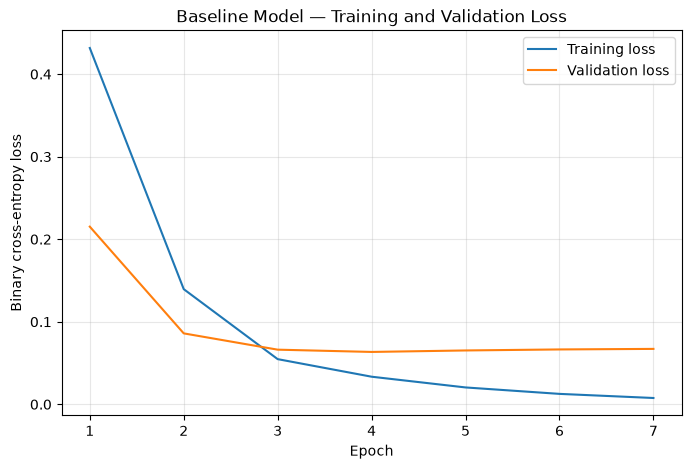

In [31]:
# ---------------------------------------------------------------------------
# Plot training and validation loss
# ---------------------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index,
    history_df["loss"],
    label="Training loss",
)

plt.plot(
    history_df.index,
    history_df["val_loss"],
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Baseline Model — Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

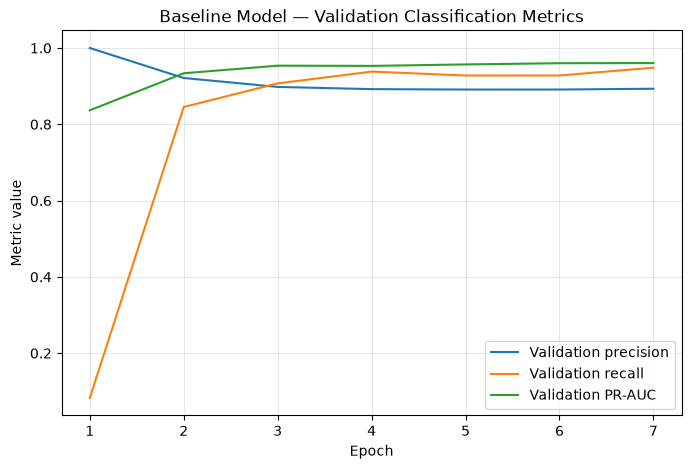

In [32]:
# ---------------------------------------------------------------------------
# Plot validation classification metrics
# ---------------------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index,
    history_df["val_precision"],
    label="Validation precision",
)

plt.plot(
    history_df.index,
    history_df["val_recall"],
    label="Validation recall",
)

plt.plot(
    history_df.index,
    history_df["val_pr_auc"],
    label="Validation PR-AUC",
)

plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("Baseline Model — Validation Classification Metrics")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [33]:
# ---------------------------------------------------------------------------
# Evaluate the restored best model on the validation split
# ---------------------------------------------------------------------------

validation_results = baseline_model.evaluate(
    X_val_vectorized,
    y_val,
    verbose=0,
    return_dict=True,
)

print("Validation metrics using restored best weights:\n")

for metric_name, metric_value in validation_results.items():
    print(f"{metric_name:10s}: {metric_value:.4f}")

Validation metrics using restored best weights:

accuracy  : 0.9780
loss      : 0.0634
pr_auc    : 0.9531
precision : 0.8922
recall    : 0.9381
roc_auc   : 0.9939


### 2.17 Evaluate classification errors at the default threshold

The model is first assessed using the standard classification threshold of 0.50.

Because the dataset is imbalanced, accuracy alone is insufficient. Precision, recall, F1-score, and the confusion matrix are used to distinguish false positives from false negatives.

For this project:

- a **false positive** means a legitimate SMS is incorrectly blocked as spam;
- a **false negative** means a spam SMS is incorrectly allowed through.

In [34]:
# ---------------------------------------------------------------------------
# Generate validation predictions at the default 0.50 threshold
# ---------------------------------------------------------------------------

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

# Predict spam probabilities using the restored best model.
val_probabilities = baseline_model.predict(
    X_val_vectorized,
    verbose=0,
).ravel()

# Convert probabilities into binary predictions.
val_predictions = (
    val_probabilities >= 0.50
).astype(int)

precision = precision_score(
    y_val,
    val_predictions,
)

recall = recall_score(
    y_val,
    val_predictions,
)

f1 = f1_score(
    y_val,
    val_predictions,
)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification report:")
print(
    classification_report(
        y_val,
        val_predictions,
        target_names=["ham", "spam"],
        digits=4,
    )
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_val,
        val_predictions,
    )
)

Precision: 0.8922
Recall:    0.9381
F1-score:  0.9146

Classification report:
              precision    recall  f1-score   support

         ham     0.9911    0.9838    0.9874       677
        spam     0.8922    0.9381    0.9146        97

    accuracy                         0.9780       774
   macro avg     0.9416    0.9609    0.9510       774
weighted avg     0.9787    0.9780    0.9783       774

Confusion matrix:
[[666  11]
 [  6  91]]


### 2.18 Baseline performance interpretation

Using the default classification threshold of 0.50, the corrected baseline achieves strong validation performance:

- **Accuracy:** 97.80%
- **Spam precision:** 89.22%
- **Spam recall:** 93.81%
- **Spam F1-score:** 91.46%
- **ROC-AUC:** 0.9939
- **PR-AUC:** 0.9531

The confusion matrix shows:

- **666 true negatives:** legitimate SMS correctly classified as ham;
- **91 true positives:** spam messages correctly detected;
- **11 false positives:** legitimate SMS incorrectly classified as spam;
- **6 false negatives:** spam messages incorrectly classified as ham.

Although overall accuracy is high, the minority-class metrics provide a more meaningful assessment because the dataset is imbalanced.

From a business perspective, false positives are particularly important because incorrectly blocking a legitimate customer message may degrade trust and communication reliability. False negatives are also undesirable because they allow unwanted spam to reach the customer.

The high ROC-AUC indicates that the model separates the two classes well. Therefore, the classification threshold can be investigated on the validation set to determine whether the precision-recall trade-off can be improved without retraining the model.

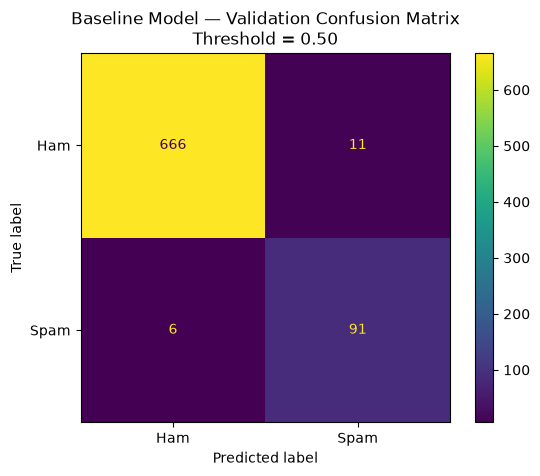

In [35]:
# ---------------------------------------------------------------------------
# Visualize the baseline validation confusion matrix
# ---------------------------------------------------------------------------

from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_val,
    val_predictions,
)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"],
)

display_cm.plot(
    values_format="d",
)

plt.title(
    "Baseline Model — Validation Confusion Matrix\n"
    "Threshold = 0.50"
)

plt.show()

### 2.20 Investigate the classification threshold

The sigmoid output represents a continuous spam score, while the default threshold of 0.50 converts that score into a binary decision.

Because false positives and false negatives have different business consequences, the threshold should not be assumed to be optimal automatically.

Candidate thresholds are evaluated exclusively on the validation set. The comparison focuses on spam precision, recall, F1-score, and the resulting false-positive and false-negative counts.

The test set remains untouched.

In [36]:
# ---------------------------------------------------------------------------
# Compare candidate classification thresholds on validation data
# ---------------------------------------------------------------------------

threshold_results = []

# Evaluate a practical range of decision thresholds.
candidate_thresholds = np.arange(
    0.10,
    0.91,
    0.05,
)

for threshold in candidate_thresholds:

    # Convert probabilities into binary predictions at this threshold.
    predictions = (
        val_probabilities >= threshold
    ).astype(int)

    # Extract confusion-matrix components.
    tn, fp, fn, tp = confusion_matrix(
        y_val,
        predictions,
    ).ravel()

    # Store minority-class metrics and business-relevant error counts.
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_val,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_val,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_val,
            predictions,
            zero_division=0,
        ),
        "false_positives": fp,
        "false_negatives": fn,
    })

threshold_df = pd.DataFrame(
    threshold_results
)

print(
    threshold_df.round(4).to_string(
        index=False
    )
)

 threshold  precision  recall     f1  false_positives  false_negatives
      0.10     0.7881  0.9588 0.8651               25                4
      0.15     0.8455  0.9588 0.8986               17                4
      0.20     0.8774  0.9588 0.9163               13                4
      0.25     0.8762  0.9485 0.9109               13                5
      0.30     0.8846  0.9485 0.9154               12                5
      0.35     0.8846  0.9485 0.9154               12                5
      0.40     0.8932  0.9485 0.9200               11                5
      0.45     0.8932  0.9485 0.9200               11                5
      0.50     0.8922  0.9381 0.9146               11                6
      0.55     0.8911  0.9278 0.9091               11                7
      0.60     0.9082  0.9175 0.9128                9                8
      0.65     0.9062  0.8969 0.9016                9               10
      0.70     0.9149  0.8866 0.9005                8               11
      

In [37]:
# ---------------------------------------------------------------------------
# Identify the threshold with the highest validation F1-score
# ---------------------------------------------------------------------------

best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("Best threshold by validation F1-score:")
print(best_threshold_row.round(4))

Best threshold by validation F1-score:
threshold           0.4000
precision           0.8932
recall              0.9485
f1                  0.9200
false_positives    11.0000
false_negatives     5.0000
Name: 6, dtype: float64


### 2.21 Select the operating threshold

Threshold analysis was performed exclusively on the validation set.

The standard threshold of 0.50 produced:

- spam precision: **0.8922**
- spam recall: **0.9381**
- spam F1-score: **0.9146**
- false positives: **11**
- false negatives: **6**

Among the evaluated candidate thresholds, **0.40** produced the highest validation F1-score:

- spam precision: **0.8932**
- spam recall: **0.9485**
- spam F1-score: **0.9200**
- false positives: **11**
- false negatives: **5**

Lowering the threshold from 0.50 to 0.40 therefore detected one additional spam message without increasing the number of legitimate messages incorrectly classified as spam.

For subsequent model comparison, **0.40 is retained as the validation-selected operating threshold for this baseline**. The standard 0.50 results are also retained as a reference.

The threshold will not be optimized on the test set in order to prevent test-set leakage.

At threshold 0.40:
Precision=TP+FP/TP=4+3/4=57.1%
Recall=TP+FN/TP=4+1/4=80%

In [38]:
# ---------------------------------------------------------------------------
# Freeze the validation-selected operating threshold
# ---------------------------------------------------------------------------

BASELINE_THRESHOLD = 0.40

print(
    f"Selected baseline classification threshold: "
    f"{BASELINE_THRESHOLD:.2f}"
)

Selected baseline classification threshold: 0.40


### 2.22 Analyze validation classification errors

Aggregate metrics do not reveal which types of SMS messages remain difficult for the model.

False positives and false negatives are therefore inspected at the selected validation threshold of 0.40.

The predicted spam probability is included to distinguish borderline mistakes from highly confident classification errors. This qualitative analysis can reveal limitations that motivate the next, more expressive sequence-based model.

In [39]:
# ---------------------------------------------------------------------------
# Build a validation prediction analysis table
# ---------------------------------------------------------------------------

val_predictions_selected = (
    val_probabilities >= BASELINE_THRESHOLD
).astype(int)

validation_error_analysis = val_df[
    ["text", "label"]
].copy()

validation_error_analysis["true_label"] = y_val.to_numpy()
validation_error_analysis["spam_probability"] = val_probabilities
validation_error_analysis["prediction"] = val_predictions_selected

# Convert numerical predictions back to readable class names.
validation_error_analysis["predicted_label"] = np.where(
    validation_error_analysis["prediction"] == 1,
    "spam",
    "ham",
)

# Keep only incorrectly classified observations.
validation_errors = validation_error_analysis[
    validation_error_analysis["true_label"]
    != validation_error_analysis["prediction"]
].copy()

print(
    f"Total validation errors at threshold "
    f"{BASELINE_THRESHOLD:.2f}: {len(validation_errors)}"
)

Total validation errors at threshold 0.40: 16


In [40]:
# ---------------------------------------------------------------------------
# Inspect false positives and false negatives separately
# ---------------------------------------------------------------------------

# False positives: legitimate SMS incorrectly flagged as spam.
false_positives = validation_errors[
    (validation_errors["true_label"] == 0)
    & (validation_errors["prediction"] == 1)
].sort_values(
    "spam_probability",
    ascending=False,
)

# False negatives: spam SMS incorrectly classified as legitimate.
false_negatives = validation_errors[
    (validation_errors["true_label"] == 1)
    & (validation_errors["prediction"] == 0)
].sort_values(
    "spam_probability",
    ascending=True,
)

print(f"False positives: {len(false_positives)}")
print(f"False negatives: {len(false_negatives)}")

False positives: 11
False negatives: 5


In [41]:
# ---------------------------------------------------------------------------
# Display false positives
# ---------------------------------------------------------------------------

pd.set_option("display.max_colwidth", None)

display(
    false_positives[
        [
            "text",
            "spam_probability",
        ]
    ]
)

,text,spam_probability
50,Waiting for your call.,0.997482
529,"Hey...Great deal...Farm tour 9am to 5pm $95/pax, $50 deposit by 16 May",0.911920
698,Ok... Ur typical reply...,0.896514
352,Hi.:)technical support.providing assistance to us customer through call and email:),0.880860
481,"Hi Shanil,Rakhesh here.thanks,i have exchanged the uncut diamond stuff.leaving back. Excellent service by Dino and Prem.",0.748702
609,"\NONE!NOWHERE IKNO DOESDISCOUNT!SHITINNIT\""""",0.722461
598,Ultimately tor motive tui achieve korli.,0.722461
515,"Tick, tick, tick ... Babe",0.712333
405,Hmm...Bad news...Hype park plaza $700 studio taken...Only left 2 bedrm-$900...,0.653900
579,"Garbage bags, eggs, jam, bread, hannaford wheat chex",0.596355


In [42]:
# ---------------------------------------------------------------------------
# Display false negatives
# ---------------------------------------------------------------------------

display(
    false_negatives[
        [
            "text",
            "spam_probability",
        ]
    ]
)

,text,spam_probability
219,dating:i have had two of these. Only started after i sent a text to talk sport radio last week. Any connection do you think or coincidence?,0.020683
726,Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rude time with a sexy bitch. How about we go slo n hard! Txt XXX SLO(4msgs),0.029224
411,For sale - arsenal dartboard. Good condition but no doubles or trebles!,0.034894
383,"Hi this is Amy, we will be sending you a free phone number in a couple of days, which will give you an access to all the adult parties...",0.045848
732,Sorry! U can not unsubscribe yet. THE MOB offer package has a min term of 54 weeks> pls resubmit request after expiry. Reply THEMOB HELP 4 more info,0.244348


### 2.23 Baseline error analysis

At the validation-selected threshold of 0.40, the baseline produces **11 false positives** and **5 false negatives**.

Inspection of the false positives suggests that several legitimate messages contain lexical patterns that resemble spam. Examples include commercial or transactional language such as *"Great deal"*, prices and currency symbols, technical-support terminology, numbers, unusual punctuation, and short or atypically phrased messages. The model can therefore associate legitimate messages containing spam-like vocabulary with the positive class.

The false negatives reveal the opposite limitation. Some spam messages are written in a conversational style or contain vocabulary that can also occur in ordinary personal communication. Others require understanding combinations of words and contextual relationships rather than detecting individual spam-associated terms.

These errors are consistent with the baseline architecture. Global average pooling combines token embeddings into a single representation without explicitly preserving word order. Consequently, the model can learn useful vocabulary-level signals but has limited ability to model sequential context.

This motivates the next experiment: a recurrent sequence model that preserves token order and can learn contextual relationships between words.

The error analysis also shows that class imbalance is not currently preventing the baseline from detecting spam: validation spam recall is approximately 94.85% at the selected threshold. Therefore, class weighting is not introduced at this stage. It can be reconsidered only if later experiments provide evidence that it is necessary.

In [43]:
# ---------------------------------------------------------------------------
# Store baseline validation metrics for later model comparison
# ---------------------------------------------------------------------------

baseline_metrics = {
    "model": "Embedding + GlobalAveragePooling1D",
    "selected_threshold": BASELINE_THRESHOLD,
    "validation_accuracy": validation_results["accuracy"],
    "validation_precision": precision_score(
        y_val,
        val_predictions_selected,
    ),
    "validation_recall": recall_score(
        y_val,
        val_predictions_selected,
    ),
    "validation_f1": f1_score(
        y_val,
        val_predictions_selected,
    ),
    "validation_roc_auc": validation_results["roc_auc"],
    "validation_pr_auc": validation_results["pr_auc"],
    "validation_false_positives": int(
        ((y_val.to_numpy() == 0) & (val_predictions_selected == 1)).sum()
    ),
    "validation_false_negatives": int(
        ((y_val.to_numpy() == 1) & (val_predictions_selected == 0)).sum()
    ),
}

baseline_metrics_df = pd.DataFrame(
    [baseline_metrics]
)

display(
    baseline_metrics_df.round(4)
)

,model,selected_threshold,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_pr_auc,validation_false_positives,validation_false_negatives
0,Embedding + GlobalAveragePooling1D,0.4,0.978,0.8932,0.9485,0.92,0.9939,0.9531,11,5


In [44]:
# ---------------------------------------------------------------------------
# Save baseline development metrics
# ---------------------------------------------------------------------------

METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"

METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BASELINE_METRICS_PATH = (
    METRICS_DIR
    / "baseline_validation_metrics.csv"
)

baseline_metrics_df.to_csv(
    BASELINE_METRICS_PATH,
    index=False,
)

print(
    f"Saved baseline metrics to: "
    f"{BASELINE_METRICS_PATH}"
)

Saved baseline metrics to: c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\4_Att-spam-detector\outputs\metrics\baseline_validation_metrics.csv


In [45]:
# ---------------------------------------------------------------------------
# Save the trained baseline model
# ---------------------------------------------------------------------------

MODELS_DIR = PROJECT_ROOT / "models"

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BASELINE_MODEL_PATH = (
    MODELS_DIR
    / "baseline_embedding_model.keras"
)

baseline_model.save(
    BASELINE_MODEL_PATH
)

print(
    f"Saved baseline model to: "
    f"{BASELINE_MODEL_PATH}"
)

Saved baseline model to: c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\4_Att-spam-detector\models\baseline_embedding_model.keras


## 2.26 Baseline conclusion

A simple embedding-based neural network was developed as the first deep-learning benchmark for the AT&T spam-classification task.

An initial training attempt exposed an important preprocessing edge case: punctuation-only SMS messages became fully padded after punctuation stripping. Combined with masked global-average pooling, this produced invalid pooled representations and caused the network to collapse to a constant prediction. The preprocessing pipeline was corrected by mapping standardized empty messages to a dedicated `[EMPTY]` token, after which no fully padded sequences remained.

The corrected baseline learned strong class separation. Early stopping identified epoch 4 as the best epoch by validation loss and restored those weights.

At the standard threshold of 0.50, the model achieved a spam F1-score of 0.9146. Validation-only threshold analysis selected an operating threshold of 0.40, improving spam recall while leaving the number of false positives unchanged.

At the selected threshold of 0.40, validation performance is:

- **Accuracy:** 0.9780
- **Spam precision:** 0.8932
- **Spam recall:** 0.9485
- **Spam F1-score:** 0.9200
- **ROC-AUC:** 0.9939
- **PR-AUC:** 0.9531
- **False positives:** 11
- **False negatives:** 5

Error analysis suggests that the baseline relies strongly on vocabulary-level signals. Legitimate messages containing commercial, numerical, or otherwise spam-like vocabulary can be incorrectly flagged, while conversationally written spam can occasionally be missed.

Because global-average pooling does not explicitly model token order, the next experiment will evaluate whether a recurrent sequence model can improve performance by learning contextual and sequential relationships between words.

The test set has not been used for model selection, threshold optimization, or error analysis and remains reserved for final evaluation.